# EDA: Condenser Fouling

## Why this fault is mechanistically different

The two faults we've EDA'd so far (undercharge, overcharge) are both **charge-level**
faults — there's simply too little or too much refrigerant in the system. Condenser
fouling is different: it's a **heat-transfer surface degradation** fault. Dirt/debris
buildup on the condenser coil reduces its ability to reject heat to the outdoor air,
regardless of how much refrigerant is in the system.

## Hypothesis (before looking at any data)

- Condenser temp and/or pressure should rise (the coil can't shed heat as efficiently,
  so refrigerant stays hotter/more pressurized on the high side).
- Capacity (`RTU_TOT_CAPA`) should drop, similar to the other faults, but for a
  different physical reason (the whole cycle is less efficient, not mis-charged).
- Severity should scale monotonically with fouling % — but given overcharge just
  taught us not to assume monotonicity, this needs to be checked, not assumed.
- Open question I genuinely don't know the answer to yet: does fouling primarily hit
  the *condenser* signals only, or does it also mess with the *evaporator/suction* side
  signals the way undercharge did? A fault that's physically located at the condenser
  might stay more localized in its data signature than a charge-level fault that affects
  the whole refrigerant loop.

## Data dictionary (same schema as notebooks 01 & 02 — all Simulated-dataset files share these 24 sensor columns + `Datetime`)

**Airside**
- `RTU_OA_FLOW`, `RTU_OA_HUM`, `RTU_OA_TEMP` — outside air: flow rate, humidity, temperature
- `RTU_RA_FLOW`, `RTU_RA_HUM`, `RTU_RA_TEMP` — return air (coming back from the space)
- `RTU_SA_FLOW`, `RTU_SA_HUM`, `RTU_SA_TEMP` — supply air (leaving the unit into the space)
- `RTU_SA_FAN_WATT` — supply fan power draw
- `ZA_TEMP`, `ZA_HUM` — zone/occupied-space temperature and humidity
- `ZA_TEMP_SPT` — thermostat setpoint (a control target, not a physical measurement)

**Refrigerant cycle**
- `RTU_REFG_SUCT_PRES`, `RTU_REFG_SUCT_TEMP` — suction line (compressor inlet, low-pressure side)
- `RTU_REFG_DISC_PRES`, `RTU_REFG_DISC_TEMP` — discharge line (compressor outlet, high-pressure side)
- `RTU_REFG_COND_PRES`, `RTU_REFG_COND_TEMP` — condenser coil (where heat rejects to outdoor air — **the subsystem this fault directly degrades**)
- `RTU_COMP_WATT` — compressor power draw

**Capacity & status**
- `RTU_SEN_CAPA` — sensible cooling capacity only (temperature-only load)
- `RTU_TOT_CAPA` — total cooling capacity (sensible + latent/humidity load) — **strongest fault signal in undercharge/overcharge so far**
- `RTU_TOT_WATT` — whole-unit power draw
- `RTU_STG_STA` — compressor stage indicator: `0.10` ≈ off, `0.67` ≈ stage 1, `1.0` ≈ stage 2 (confirmed empirically in notebook 01)

**Known caveat carried forward:** the three `_PRES` columns are labeled as Pascals but are miscalibrated roughly 14–15x vs. real R410A physics (confirmed against expected saturation pressure in notebook 01). Still internally consistent, so fine to use as *relative* signals (deltas, ratios, z-scores) — just don't treat the absolute values as physically real.

In [1]:
import pandas as pd

files = {
    "baseline": "../data/raw/RTU_sim_baseline.csv",
    "condfouling10": "../data/raw/RTU_sim_condfouling10.csv",
    "condfouling20": "../data/raw/RTU_sim_condfouling20.csv",
    "condfouling30": "../data/raw/RTU_sim_condfouling30.csv",
    "condfouling40": "../data/raw/RTU_sim_condfouling40.csv",
    "condfouling50": "../data/raw/RTU_sim_condfouling50.csv",
}

dfs = {label: pd.read_csv(fname) for label, fname in files.items()}

for label, df in dfs.items():
    print(f"{label}: shape={df.shape}, missing_values={df.isna().sum().sum()}")

baseline: shape=(143941, 25), missing_values=0
condfouling10: shape=(143941, 25), missing_values=0
condfouling20: shape=(143941, 25), missing_values=0
condfouling30: shape=(143941, 25), missing_values=0
condfouling40: shape=(143941, 25), missing_values=0
condfouling50: shape=(143941, 25), missing_values=0


In [ ]:
import sys
from pathlib import Path

# ml/ is not an installed package (see ml/pyproject.toml: package-mode = false —
# deliberate, since ml/ isn't a deployed service). Notebooks live in ml/notebooks/,
# so add the ml/ root to sys.path to make `from src.features...` imports work
# consistently, the same way pytest's pythonpath = ["."] setting already does
# for the test suite.
ml_root = Path.cwd().parent
if str(ml_root) not in sys.path:
    sys.path.insert(0, str(ml_root))

from src.features.effect_size import cohens_d  # noqa: E402
from src.features.filtering import stage2_only  # noqa: E402

In [4]:
print(dfs["baseline"]["Datetime"].dtype)

object


In [5]:
for df in dfs.values():
    df["Datetime"] = pd.to_datetime(df["Datetime"])

print(dfs["baseline"]["Datetime"].dtype)

datetime64[ns]


In [6]:
stage2_dfs = {label: stage2_only(df) for label, df in dfs.items()}
print(stage2_dfs["baseline"]["Datetime"].dtype)

datetime64[ns]


In [7]:
cond_cols = ["RTU_REFG_COND_PRES", "RTU_REFG_COND_TEMP", "RTU_TOT_CAPA"]

summary = pd.DataFrame({
    label: df[cond_cols].mean()
    for label, df in dfs.items()
}).T

# keep severities in a sensible order rather than dict-insertion order
severity_order = ["baseline", "condfouling10", "condfouling20", "condfouling30", "condfouling40", "condfouling50"]
summary = summary.loc[severity_order]

summary

,RTU_REFG_COND_PRES,RTU_REFG_COND_TEMP,RTU_TOT_CAPA
baseline,2.440951e+07,77.551184,11801.510557
condfouling10,2.480461e+07,78.596570,11733.759396
condfouling20,2.533746e+07,80.011641,11723.057583
condfouling30,2.602379e+07,81.779928,11666.206914
condfouling40,2.701597e+07,84.231053,11599.900336
condfouling50,2.843253e+07,87.689402,11493.720847


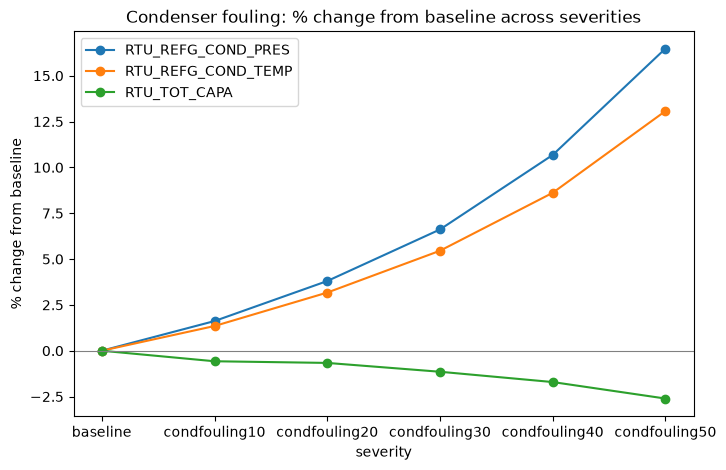

,RTU_REFG_COND_PRES,RTU_REFG_COND_TEMP,RTU_TOT_CAPA
baseline,0.000000,0.000000,0.000000
condfouling10,1.618639,1.347995,-0.574089
condfouling20,3.801607,3.172687,-0.664771
condfouling30,6.613321,5.452842,-1.146494
condfouling40,10.678046,8.613496,-1.708343
condfouling50,16.481350,13.072937,-2.608054


In [8]:
import matplotlib.pyplot as plt

pct_change = (summary / summary.loc["baseline"] - 1) * 100

fig, ax = plt.subplots(figsize=(8, 5))
for col in cond_cols:
    ax.plot(pct_change.index, pct_change[col], marker="o", label=col)

ax.set_ylabel("% change from baseline")
ax.set_xlabel("severity")
ax.set_title("Condenser fouling: % change from baseline across severities")
ax.axhline(0, color="gray", linewidth=0.8)
ax.legend()
plt.show()

pct_change

## Finding: condenser fouling is monotonic and accelerating — no charge-fault-style confound needed

Unlike undercharge/overcharge, all three signals move **monotonically** across every
severity step, on raw unfiltered data, with no compressor-stage filtering required:

| Severity | COND_PRES (%) | COND_TEMP (%) | TOT_CAPA (%) |
|---|---|---|---|
| 10% | +1.62 | +1.35 | -0.57 |
| 20% | +3.80 | +3.17 | -0.66 |
| 30% | +6.61 | +5.45 | -1.15 |
| 40% | +10.68 | +8.61 | -1.71 |
| 50% | +16.48 | +13.07 | -2.61 |

**Condenser pressure and temperature both accelerate** — each successive 10% of fouling
moves the signal more than the last step did (e.g. COND_PRES's own step-to-step deltas:
+1.62, +2.18, +2.81, +4.07, +5.80 — growing every time, not constant). This is
mechanistically sensible: fouling builds up as a physical layer on the coil surface,
and each added increment of buildup further chokes an already-degraded heat-transfer
surface, so the marginal impact of "more dirt" compounds rather than staying flat.

**`RTU_TOT_CAPA`'s drop does *not* accelerate the same way.** Its magnitude is far
smaller throughout (max -2.61% at 50% fouling, vs. condenser temp's +13.07%), and its
step-to-step deltas (-0.57, -0.09, -0.48, -0.56, -0.90) are much noisier/flatter than
the condenser columns' clean acceleration — not a smooth curve of the same shape.

**not yet resolved:** is capacity's much weaker, noisier response a real
physical finding (condenser fouling genuinely hits total capacity less hard than it hits
the condenser subsystem itself, since capacity also depends on evaporator/airside
conditions that fouling doesn't touch directly), or is some of this noise the same
kind of compressor-stage blending confound that affected undercharge/overcharge's
capacity numbers? This has **not** been checked yet — no stage filter has been applied
in this notebook. Given how weak charge-fault confounds turned out to matter a lot for
capacity specifically, this needs verifying, not assuming, before treating capacity as
"fouling barely affects it."

## Checking for a compressor-stage confound in capacity

Undercharge and overcharge both showed that `RTU_TOT_CAPA` can look artificially noisy
or muted when stage-1 and stage-2 operation are blended together in a raw mean — the
fix both times was filtering to stage-2-only rows (`RTU_STG_STA` bucket, using the same
bins established in notebook 01: off <0.3, stage1 0.3–0.9, stage2 >0.9).

Before treating condenser fouling's weak/noisy capacity response as a genuine physical
finding, the same filter needs to be applied here — this is not assumed to fix it
(fouling is a different mechanism than the charge faults, so there's no guarantee the
same confound applies), it's a real check.

In [9]:
def stage2_only(df: pd.DataFrame, stage_col: str = "RTU_STG_STA") -> pd.DataFrame:
    """Filter a telemetry dataframe to compressor stage-2 rows only.

    Uses the same stage bucketing established in notebook 01 (off <0.3,
    stage1 0.3-0.9, stage2 >0.9) to isolate steady, full-capacity operation
    from the noisier off/staging-transition periods that can blend into and
    mute or distort a fault's true signal in a raw, unfiltered mean.

    Args:
        df: A single fault-severity telemetry dataframe.
        stage_col: Column holding the compressor stage indicator.

    Returns:
        A copy containing only rows where the unit is in stage 2.
    """
    return df[df[stage_col] > 0.9].copy()


stage2_summary = pd.DataFrame({
    label: df[cond_cols].mean()
    for label, df in stage2_dfs.items()
}).T.loc[severity_order]

stage2_pct_change = (stage2_summary / stage2_summary.loc["baseline"] - 1) * 100
stage2_pct_change

,RTU_REFG_COND_PRES,RTU_REFG_COND_TEMP,RTU_TOT_CAPA
baseline,0.000000,0.000000,0.000000
condfouling10,2.322908,1.898334,-0.305028
condfouling20,4.750519,3.856863,-1.378033
condfouling30,8.356893,6.699914,-2.155787
condfouling40,14.297094,11.215160,-2.021121
condfouling50,21.071451,16.174487,-4.457749


In [10]:
for label, df in stage2_dfs.items():
    print(f"{label}: stage2 rows = {len(df)} (of {len(dfs[label])} total, {100*len(df)/len(dfs[label]):.1f}%)")

baseline: stage2 rows = 63190 (of 143941 total, 43.9%)
condfouling10: stage2 rows = 62952 (of 143941 total, 43.7%)
condfouling20: stage2 rows = 63470 (of 143941 total, 44.1%)
condfouling30: stage2 rows = 63496 (of 143941 total, 44.1%)
condfouling40: stage2 rows = 62951 (of 143941 total, 43.7%)
condfouling50: stage2 rows = 63277 (of 143941 total, 44.0%)


## Finding: capacity's response is non-monotonic even after stage-2 filtering — genuinely unresolved

Stage-2 filtering was applied (same method as undercharge/overcharge, `stage2_only()`)
to check whether it would clean up capacity's weaker, noisier response relative to the
condenser signals. It did **not**:

| Severity | Unfiltered TOT_CAPA (%) | Stage2-filtered TOT_CAPA (%) |
|---|---|---|
| 10% | -0.57 | -0.31 |
| 20% | -0.66 | -1.38 |
| 30% | -1.15 | -2.16 |
| 40% | -1.71 | **-2.02** |
| 50% | -2.61 | -4.46 |

The filtered series is **non-monotonic**: 30%→40% goes from -2.16% to -2.02%, a real dip
in magnitude where every other step (filtered or not) gets more negative. Unlike
undercharge, where filtering revealed a clean signal, here filtering made capacity's
behavior *more* erratic, not less.

**Checked and ruled out:** stage-2 sample size as an explanation. Every file's stage-2
subset is 43.7-44.1% of total rows (62,951-63,496 out of 143,941) — condfouling40 is not
under-sampled relative to its neighbors, so this isn't a smaller/noisier-subset artifact.

**Genuinely unresolved.** Two condenser-side signals (pressure, temperature) are clean,
monotonic, and accelerating both before and after filtering. Capacity is not, in either
version. Possible explanations not yet checked: capacity depends on airside/evaporator
conditions the condenser-side filter doesn't touch, so a confound sitting elsewhere in
the airside sensors (not compressor staging) may be at play; or this may be a case where
condenser fouling's effect on total capacity is small enough in absolute terms that
normal day-to-day/weather-driven variance in the underlying simulation dominates the
signal at these severities. Neither has been verified against the data — left open, the
same way overcharge's non-monotonic discharge pressure was left open, rather than
picking an explanation without checking it.

## Investigating the capacity wobble: is it a distribution issue or a few noisy days?

A mean can hide a lot — it can't distinguish "the whole distribution shifted a little"
from "a handful of anomalous days dragged the average." Before leaving this open,
plot the actual time series (not just the mean) for baseline vs. the file showing the
dip (condfouling40), stage-2 filtered, to see the shape directly.

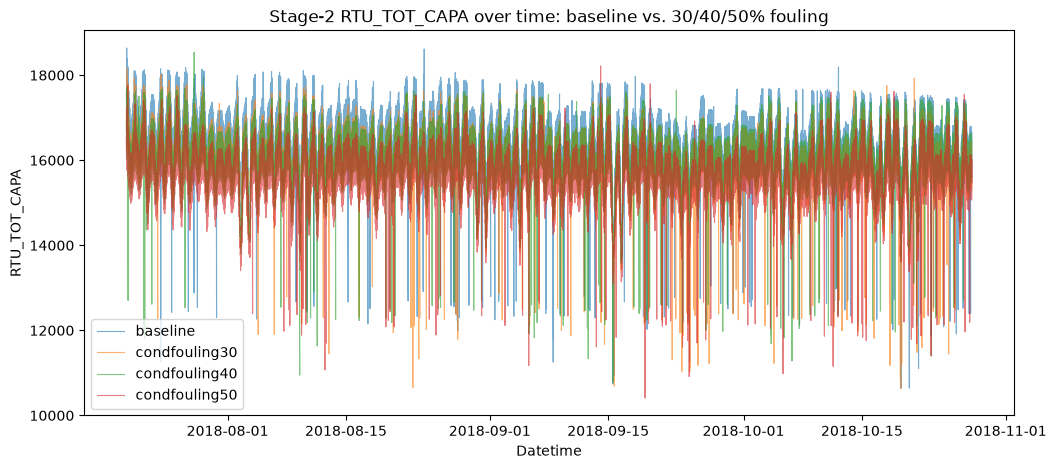

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))

for label in ["baseline", "condfouling30", "condfouling40", "condfouling50"]:
    df = stage2_dfs[label]
    ax.plot(df["Datetime"], df["RTU_TOT_CAPA"], label=label, alpha=0.6, linewidth=0.8)

ax.set_ylabel("RTU_TOT_CAPA")
ax.set_xlabel("Datetime")
ax.set_title("Stage-2 RTU_TOT_CAPA over time: baseline vs. 30/40/50% fouling")
ax.legend()
plt.show()

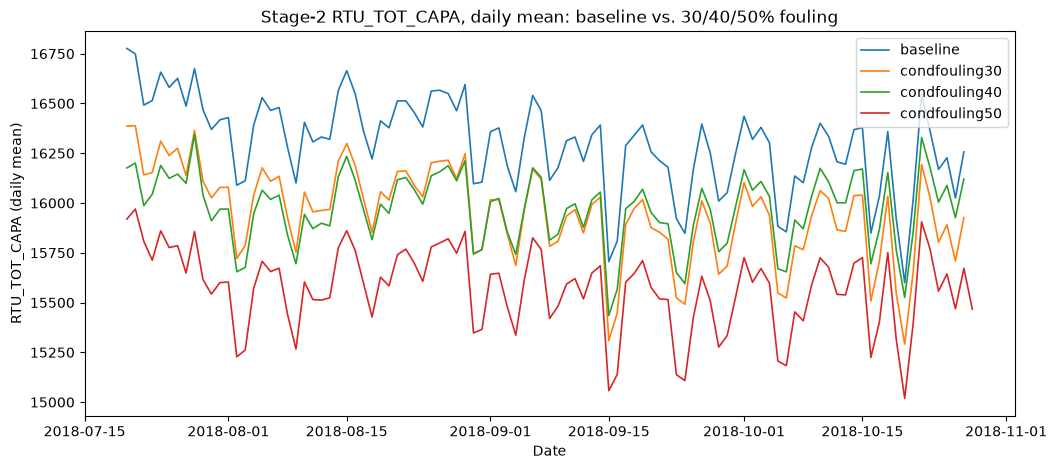

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))

for label in ["baseline", "condfouling30", "condfouling40", "condfouling50"]:
    df = stage2_dfs[label]
    daily = df.set_index("Datetime")["RTU_TOT_CAPA"].resample("D").mean()
    ax.plot(daily.index, daily.values, label=label, linewidth=1.2)

ax.set_ylabel("RTU_TOT_CAPA (daily mean)")
ax.set_xlabel("Date")
ax.set_title("Stage-2 RTU_TOT_CAPA, daily mean: baseline vs. 30/40/50% fouling")
ax.legend()
plt.show()

## Resolution: the capacity wobble is real, not an artifact — 30% and 40% fouling are not
## cleanly separable in capacity, unlike the condenser signals

Daily-mean resampling (to average out intra-day cycling that swamped the raw
minute-level plot) makes the picture clear: baseline and condfouling50 are each
cleanly separated bands, with no overlap. **condfouling30 and condfouling40, however,
visibly interleave and cross throughout the entire ~3.5-month period** — on any given
day, either one can sit above the other.

This explains the non-monotonic mean seen earlier (-2.16% at 30% vs. -2.02% at 40%,
stage-2 filtered): it isn't a computation bug, a sample-size artifact (already ruled
out — both severities have near-identical stage-2 row counts), or a filtering
confound. It's a genuine finding: **condenser fouling's effect on total capacity is
small enough, at these severities, that day-to-day operating variance is comparable
to or larger than the 30%→40% incremental fouling effect** — unlike condenser
pressure/temperature, where every severity step is cleanly, visibly separated from
its neighbors even in the raw noisy signal.

**Practical implication for later modeling**: `RTU_TOT_CAPA` alone would likely
struggle to distinguish condfouling30 from condfouling40 as a classification feature,
even though it can clearly distinguish fouling-vs-baseline or the more separated
severities (10 vs 50). The condenser pressure/temperature columns are the far
stronger, cleaner signal for this specific fault — the opposite of undercharge,
where capacity was the single strongest signal found.

In [13]:
d_30_vs_40 = cohens_d(
    stage2_dfs["condfouling30"]["RTU_TOT_CAPA"],
    stage2_dfs["condfouling40"]["RTU_TOT_CAPA"],
)
d_baseline_vs_50 = cohens_d(
    stage2_dfs["baseline"]["RTU_TOT_CAPA"],
    stage2_dfs["condfouling50"]["RTU_TOT_CAPA"],
)

print(f"Cohen's d, condfouling30 vs condfouling40: {d_30_vs_40:.3f}")
print(f"Cohen's d, baseline vs condfouling50: {d_baseline_vs_50:.3f}")

Cohen's d, condfouling30 vs condfouling40: -0.037
Cohen's d, baseline vs condfouling50: 1.201


## Cohen's d confirms the visual read

- `condfouling30` vs `condfouling40` (stage-2 `RTU_TOT_CAPA`): **d = -0.037** — negligible,
  effectively no distinguishable difference between these two severities on this feature.
  This is not noise in the *calculation*, it's a real, small, quantified effect size
  confirming what the daily-mean plot showed visually.
- `baseline` vs `condfouling50`: **d = 1.201** — large, confirming clean separation at
  the two extremes.

**Conclusion, now backed by a number rather than an impression**: `RTU_TOT_CAPA` can
distinguish fouling from baseline, and can distinguish the extremes (10% vs 50%), but
loses discriminating power between adjacent mid-range severities (30% vs 40%). This
matters directly for later modeling — a classifier relying on capacity alone would
likely confuse these two severities specifically, and the condenser pressure/temperature
columns (cleanly separated at every step, per the earlier % change table) are the
features actually carrying this fault's signal at fine severity resolution.

## Summary: condenser fouling EDA

**Confirmed hypothesis**: condenser fouling behaves as a genuinely different fault
mechanism from the charge-level faults (undercharge/overcharge) — condenser pressure
and temperature rise monotonically and *accelerate* with severity (mechanistically
sensible: compounding heat-transfer degradation from a growing surface layer), with
no compressor-stage confound needed at all — unlike both charge faults, which required
stage-2 filtering to reveal a clean signal.

**Strongest signals**: `RTU_REFG_COND_PRES` and `RTU_REFG_COND_TEMP`, cleanly separated
at every severity step (10% through 50%), both before and after stage filtering.

**Weakest signal, and why**: `RTU_TOT_CAPA` — real effect at the extremes (baseline vs.
50%, d=1.201) but negligible between adjacent mid-severities (30% vs 40%, d=-0.037,
confirmed both visually via daily-mean resampling and numerically via Cohen's d, not
assumed from the raw noisy mean alone). Likely because capacity also depends on
airside/evaporator conditions this fault doesn't directly touch — unproven, left open.

**Practical implication for modeling**: for condenser fouling specifically, condenser
pressure/temperature are the features to weight most heavily; capacity alone would
likely struggle to distinguish 30% from 40% severity.

**Open question carried forward**: does evaporator fouling (next notebook) show the
same pattern — clean, accelerating signal on its own subsystem's sensors, weaker/muddier
signal on total capacity — or does a fault on the airside of the loop hit capacity
differently, since capacity is arguably "closer" to the evaporator/airside physically
than to the condenser?